<a target="_blank" href="https://colab.research.google.com/github/DDM-Lab/2025AI-SDM-SpeedyIBL-tutorial/blob/main/iblagent-tutorial-blank.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Using SpeedyIBL for a 2D Navigation Task
<a target="_parent">
    <img src="https://ngocntkt.github.io/visualization-map/ibl-navigation.png" width="80%" style="background-color:white";/>
</a> 

### Step 1: Define the Environment

The environment is a 4 × 6 grid that contains targets and a terminal cliff region. The agent starts at an initial position and has a 20-step limit to explore the space by making sequential decisions: moving up, down, left, or right.

*The environment is hidden from the agent. It only learns about the structure, movement costs, and the location of targets through its own interactions. In other words, by learning from experience.*

The objective is to reach the highest-value target while minimizing unnecessary movements and penalties.

[[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [240.   0.   0.   0.   0.   0.]]


(<Figure size 1800x1200 with 1 Axes>, <Axes: >)

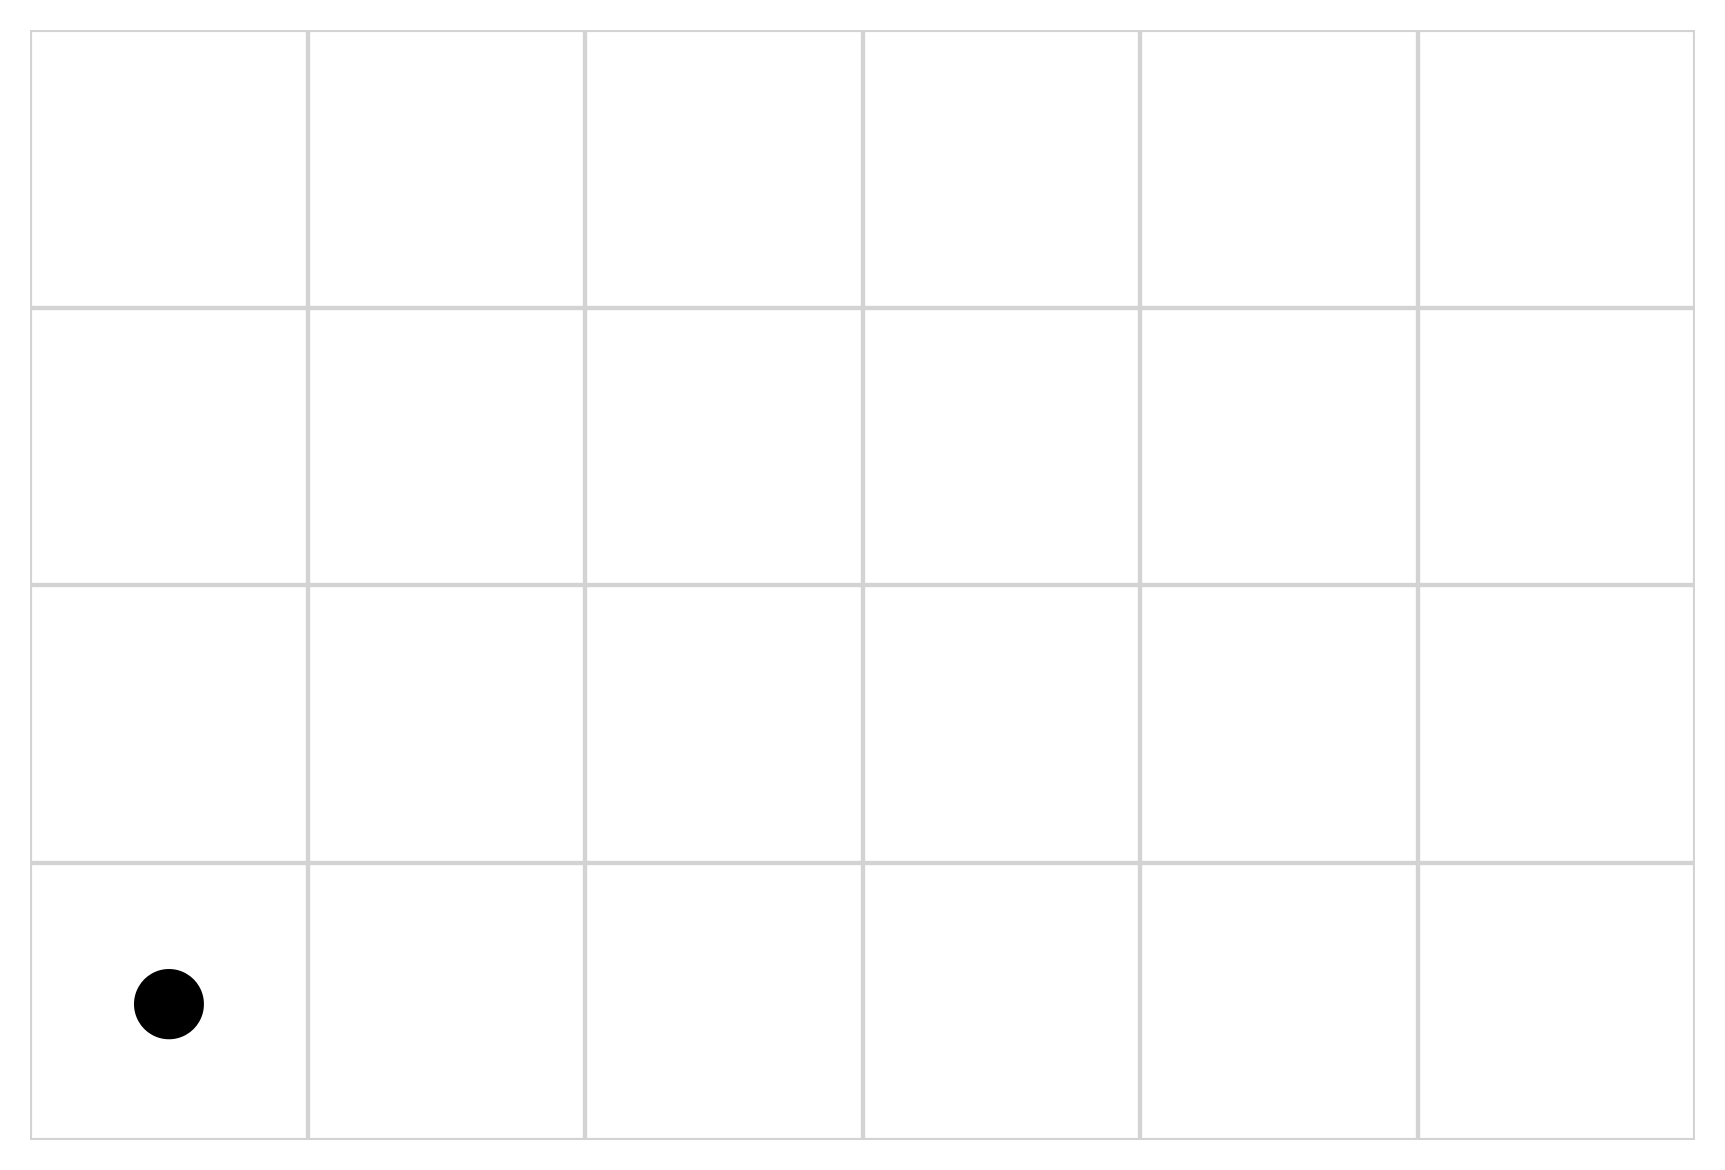

In [23]:
from gridworld import Environment 
env = Environment()
s = env.reset()
print(s)
env.plot_grid("agent")

In [24]:
s_hash = hash(s.tobytes())
options = [(s_hash,a) for a in range(env.ACTIONS)]
print(options)


[(7120486979636280654, 0), (7120486979636280654, 1), (7120486979636280654, 2), (7120486979636280654, 3)]


### Step 2: Define an IBL agent

<a target="_parent">
    <img src="https://ngocntkt.github.io/visualization-map/ibl-agent.png" width="40%" style="background-color:white";/>
</a> 

In [25]:
#%pip install speedyibl

Note: you may need to restart the kernel to use updated packages.


In [26]:
from speedyibl import Agent

In [27]:
help(Agent.__init__)

Help on function __init__ in module speedyibl.speedyibl:

__init__(self, default_utility=0.1, noise=0.25, decay=0.5, mismatchPenalty=None, outcome=True, lendeque=250000)
    Initialize self.  See help(type(self)) for accurate signature.



In [28]:
agent = Agent(default_utility=15)

### Step 3: The agent interacts with the environment
<a target="_parent">
    <img src="https://ngocntkt.github.io/visualization-map/ibl-agent-2.png" width="80%" style="background-color:white";/>
</a> 

In [29]:
choice = agent.choose(options)
action =  choice[1]
print(choice)
print(action)

(7120486979636280654, 1)
1


### Step 4: The agent observes a new observation and feedback 

<a target="_parent">
    <img src="https://ngocntkt.github.io/visualization-map/ibl-agent-3.png" width="80%" style="background-color:white";/>
</a> 

Agent observes from the environment

In [30]:
s, rstep, terminal, agent_x, agent_y = env.step(action)
print(s, rstep, terminal, agent_x, agent_y)

[[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 240.   0.   0.   0.   0.]] -1 False 1 3


### Step 5: The agent stores the experience in memory

<a target="_parent">
    <img src="https://ngocntkt.github.io/visualization-map/ibl-agent-4.png" width="80%" style="background-color:white";/>
</a> 


Agent stores the experience (situation + action + outcome) as a new instance in memory 

In [31]:
print("Memory before", agent.instances())

option    outcome    occurences
--------  ---------  ------------
Memory before None


In [32]:
agent.respond(rstep)

In [33]:
agent.instances()

option                      outcome  occurences
------------------------  ---------  ------------
(7120486979636280654, 1)         -1  [1]
(7120486979636280654, 1)         15  [0]



### Step 6: The agent repeats the process to make a sequence of action
So far, the agent performs a single step in the sequential decision-making task, which consists of choosing an option, observing the reward, and storing the experience (response). 

In [34]:
def run_ibl_episode(agent, env):
    s = env.reset()
    trajectory = []
    rewards = []
    final_r = 0.0
    episode_history = []
    total_return = 0 
    for j in range(env.MAX_STEPS):
        s_hash = hash(s.tobytes())
        options = [(s_hash, a) for a in range(env.ACTIONS)]
        choice = agent.choose(options)
        action = choice[1]
        s, rstep, terminal, agent_x, agent_y = env.step(action)
        agent.respond(rstep)
        rewards.append(rstep)
        trajectory.append((agent_x, agent_y))
        episode_history.append((choice[0], choice[1], rstep, j))
        final_r = rstep
        if terminal or j==env.MAX_STEPS-1:
            total_return = float(sum(rewards))
            agent.equal_delay_feedback(total_return, episode_history)
            break
    return final_r, total_return, episode_history, trajectory


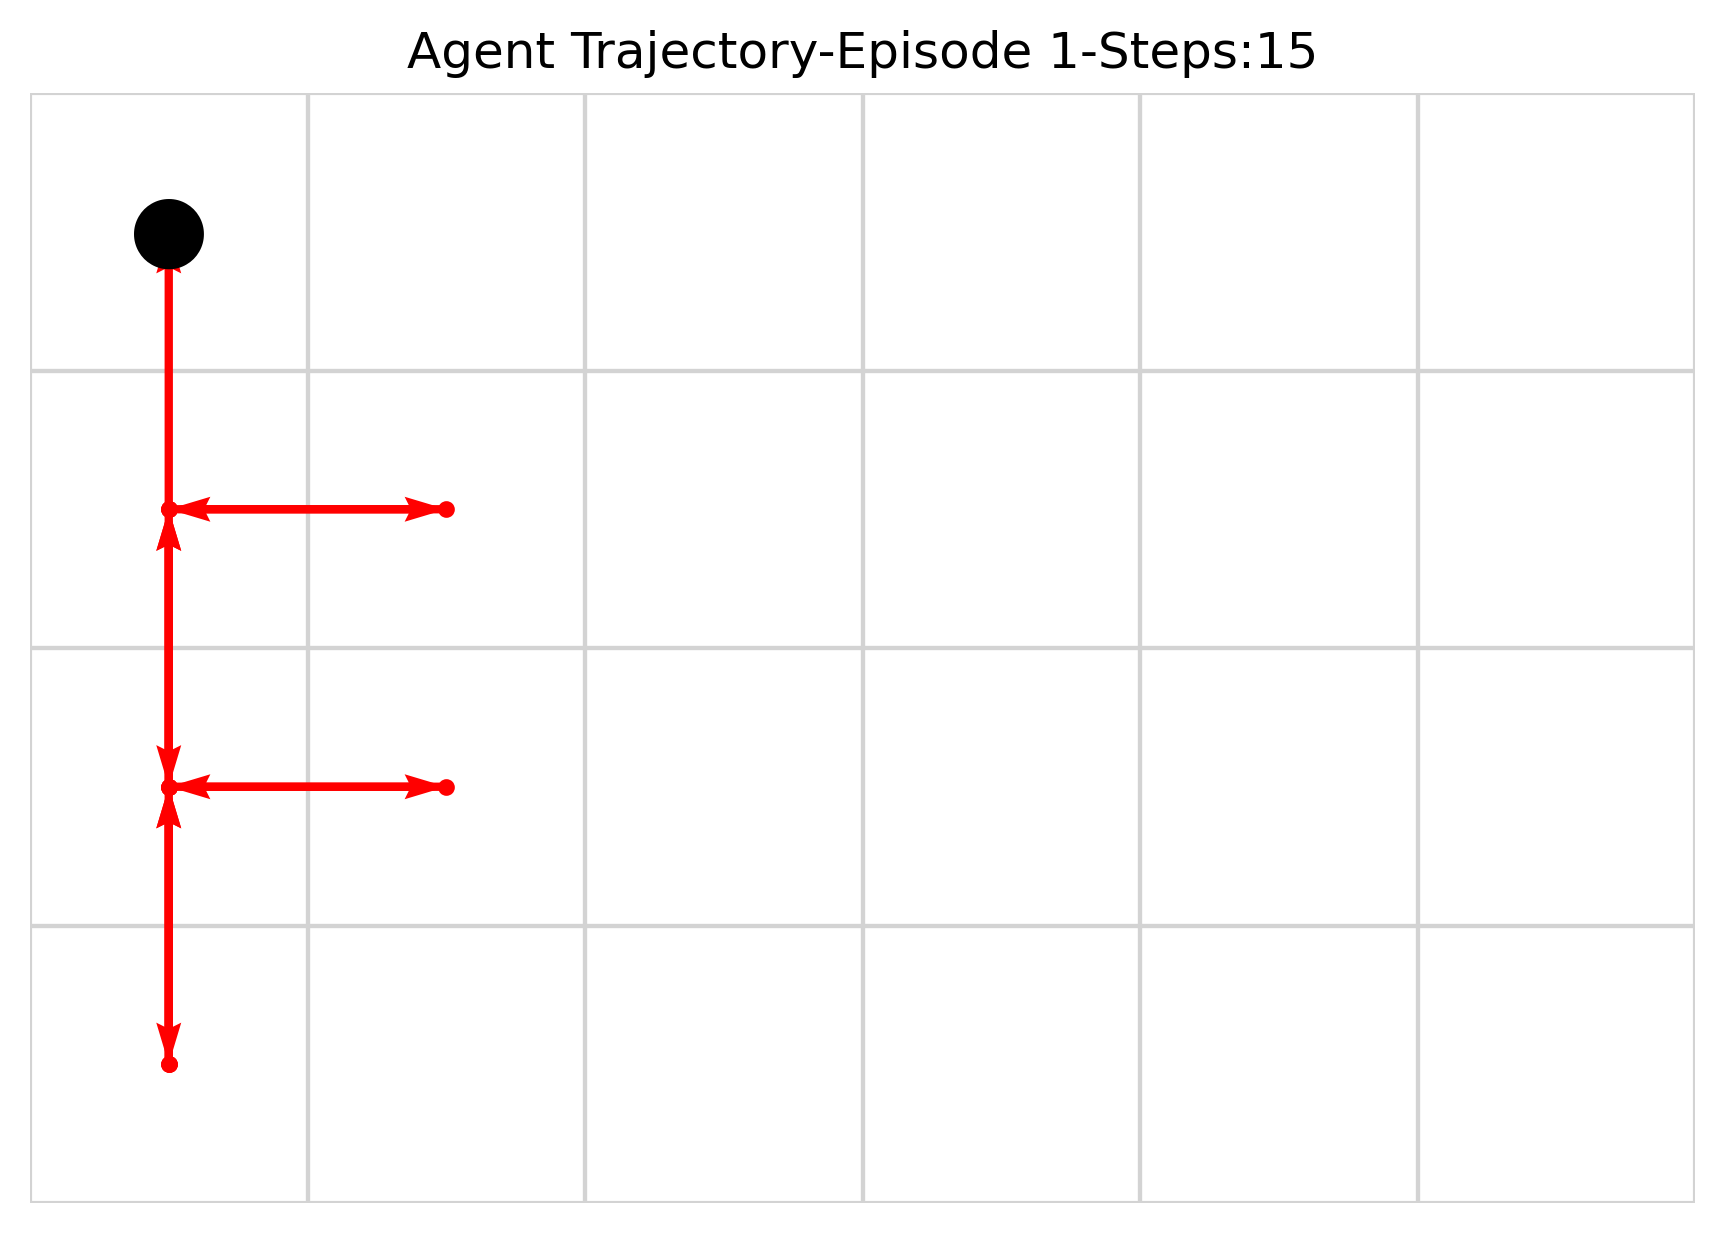

In [35]:
from util import plot_trajectory
_, _, _, trajectory = run_ibl_episode(agent, env)
trajectories = [trajectory]
plot_trajectory(env, trajectories, episode=0, testing=False)

### Functions for Analysis

Compute activation values for each **instance**

In [36]:
import numpy as np
s = np.array([[0., 0., 0., 0., 0., 0.],
              [0., 0., 0., 0., 0., 0.],
              [0., 0., 0., 0., 0., 0.],
              [0., 240., 0., 0., 0., 0.]])
for a in range(env.ACTIONS):
    print(agent.CompActivation(agent.t+1, (hash(s.tobytes()), a)))

(array([-1.17038367]), array([15]))
(array([-1.43063318]), array([15]))
(array([-1.48274391]), array([15]))
(array([-0.95633961]), array([15]))


Compute the retrieval probability for each **instance**

In [37]:
for a in range(env.ACTIONS):
    print(agent.CompProbability(agent.t+1, (hash(s.tobytes()),a)))

(array([1.]), array([15]))
(array([1.]), array([15]))
(array([1.]), array([15]))
(array([1.]), array([15]))


Compute the Blended values for each **option**

In [38]:
options = [(hash(s.tobytes()),a) for a in range(env.ACTIONS)]
agent.CompBlended(agent.t+1, options)

[(15.0, 0), (15.0, 1), (15.0, 2), (15.0, 3)]

### Putting it all together: IBL Agent in the treasure-hunting 2D navigation task

So far, the agent runs a full episode, **a sequence of such steps**, until the termination conditions are met. 

We repeat this process for 100 episodes.

In [39]:
def train_ibl(agent, env, episodes=50):
    preward = []
    otarget = []
    subtarget = []
    for i in range(episodes):
        final_r, _total_return, episode_hist, traj = run_ibl_episode(agent, env)    
        preward.append(final_r)
        otarget.append(final_r == 50) 
        subtarget.append(final_r == 5) 
    return np.array(preward), np.array(otarget), np.array(subtarget)

In [40]:
def run_ibl_maps(agent, env, episodes=50, base=None, map_fn=None):
    if map_fn is None:
        from util import compute_ibl_map as map_fn
    agent.reset()
    maps = [map_fn(agent, env, base)]
    for _ in range(episodes):
        final_r, _total_return, _hist, _traj = run_ibl_episode(agent, env)
        maps.append(map_fn(agent, env, base))
    return maps

In [ ]:
from util import show_ibl_maps_widget,compute_ibl_map
maps, slider, out, refresh = show_ibl_maps_widget(
    run_ibl_maps, agent, env, episodes=100, map_fn=compute_ibl_map
)

IntSlider(value=0, continuous_update=False, description='Episode')

Output()

### Replicate Results Across 100 Runs (Simulated Agents) and Results

In [42]:
runs = 100 
episodes = 100 

all_runs_rewards = []    
all_runs_opt = []
all_runs_subopt = [] 
episode_history= []

for _ in range(runs):
    agent.reset() #a new agent
    fr, opt, sub = train_ibl(agent, env, episodes=episodes)
    all_runs_rewards.append(fr)
    all_runs_opt.append(opt)
    all_runs_subopt.append(sub)

all_runs_rewards = np.array(all_runs_rewards) 

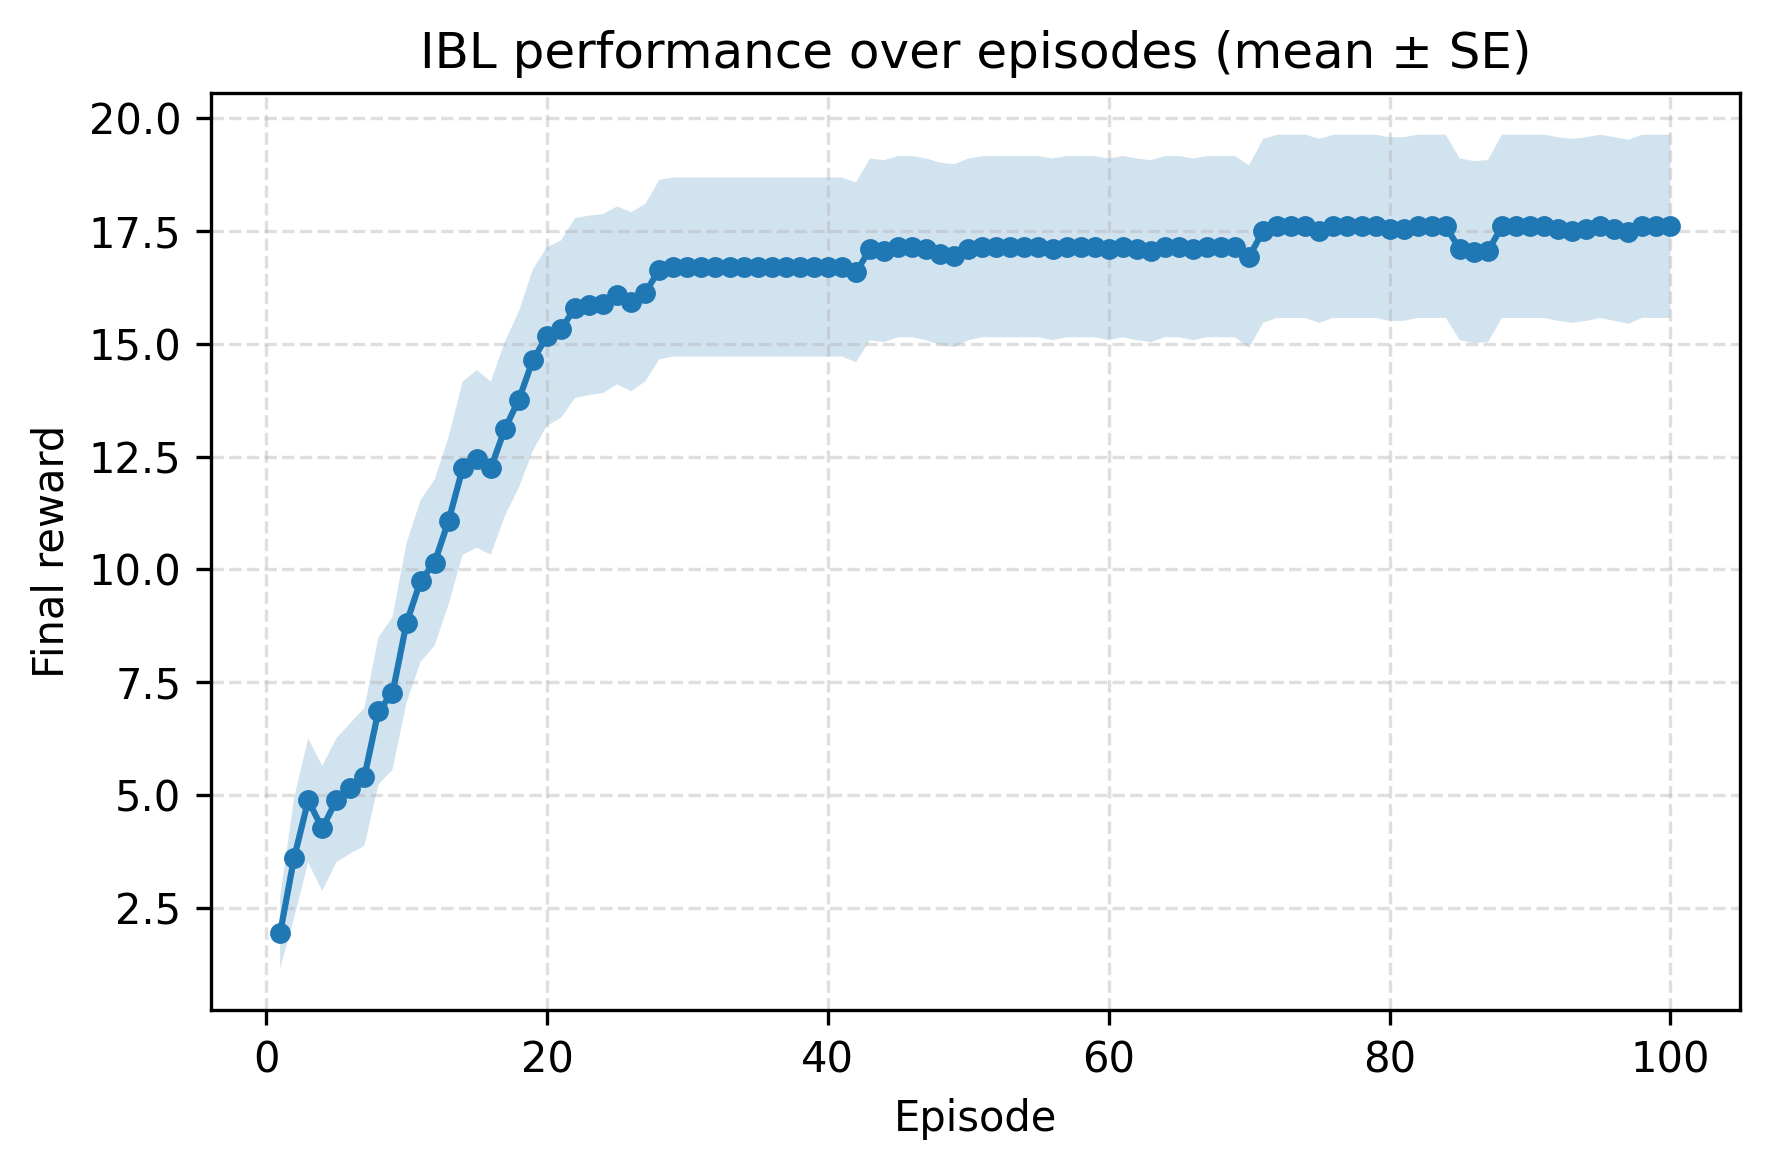

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

all_runs_rewards = np.array(all_runs_rewards)
mean_rewards = all_runs_rewards.mean(axis=0)
std_rewards = all_runs_rewards.std(axis=0, ddof=1)
n_runs = all_runs_rewards.shape[0]
se_rewards = std_rewards / np.sqrt(n_runs)

episodes = np.arange(1, mean_rewards.shape[0] + 1)

plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "sans-serif"

plt.figure(figsize=(6, 4))
plt.plot(episodes, mean_rewards, marker="o", markersize=4, linewidth=1.5, label="Mean final reward")
plt.fill_between(episodes, mean_rewards - se_rewards, mean_rewards + se_rewards, alpha=0.2)

plt.xlabel("Episode")
plt.ylabel("Final reward")
plt.title("IBL performance over episodes (mean ± SE)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
    


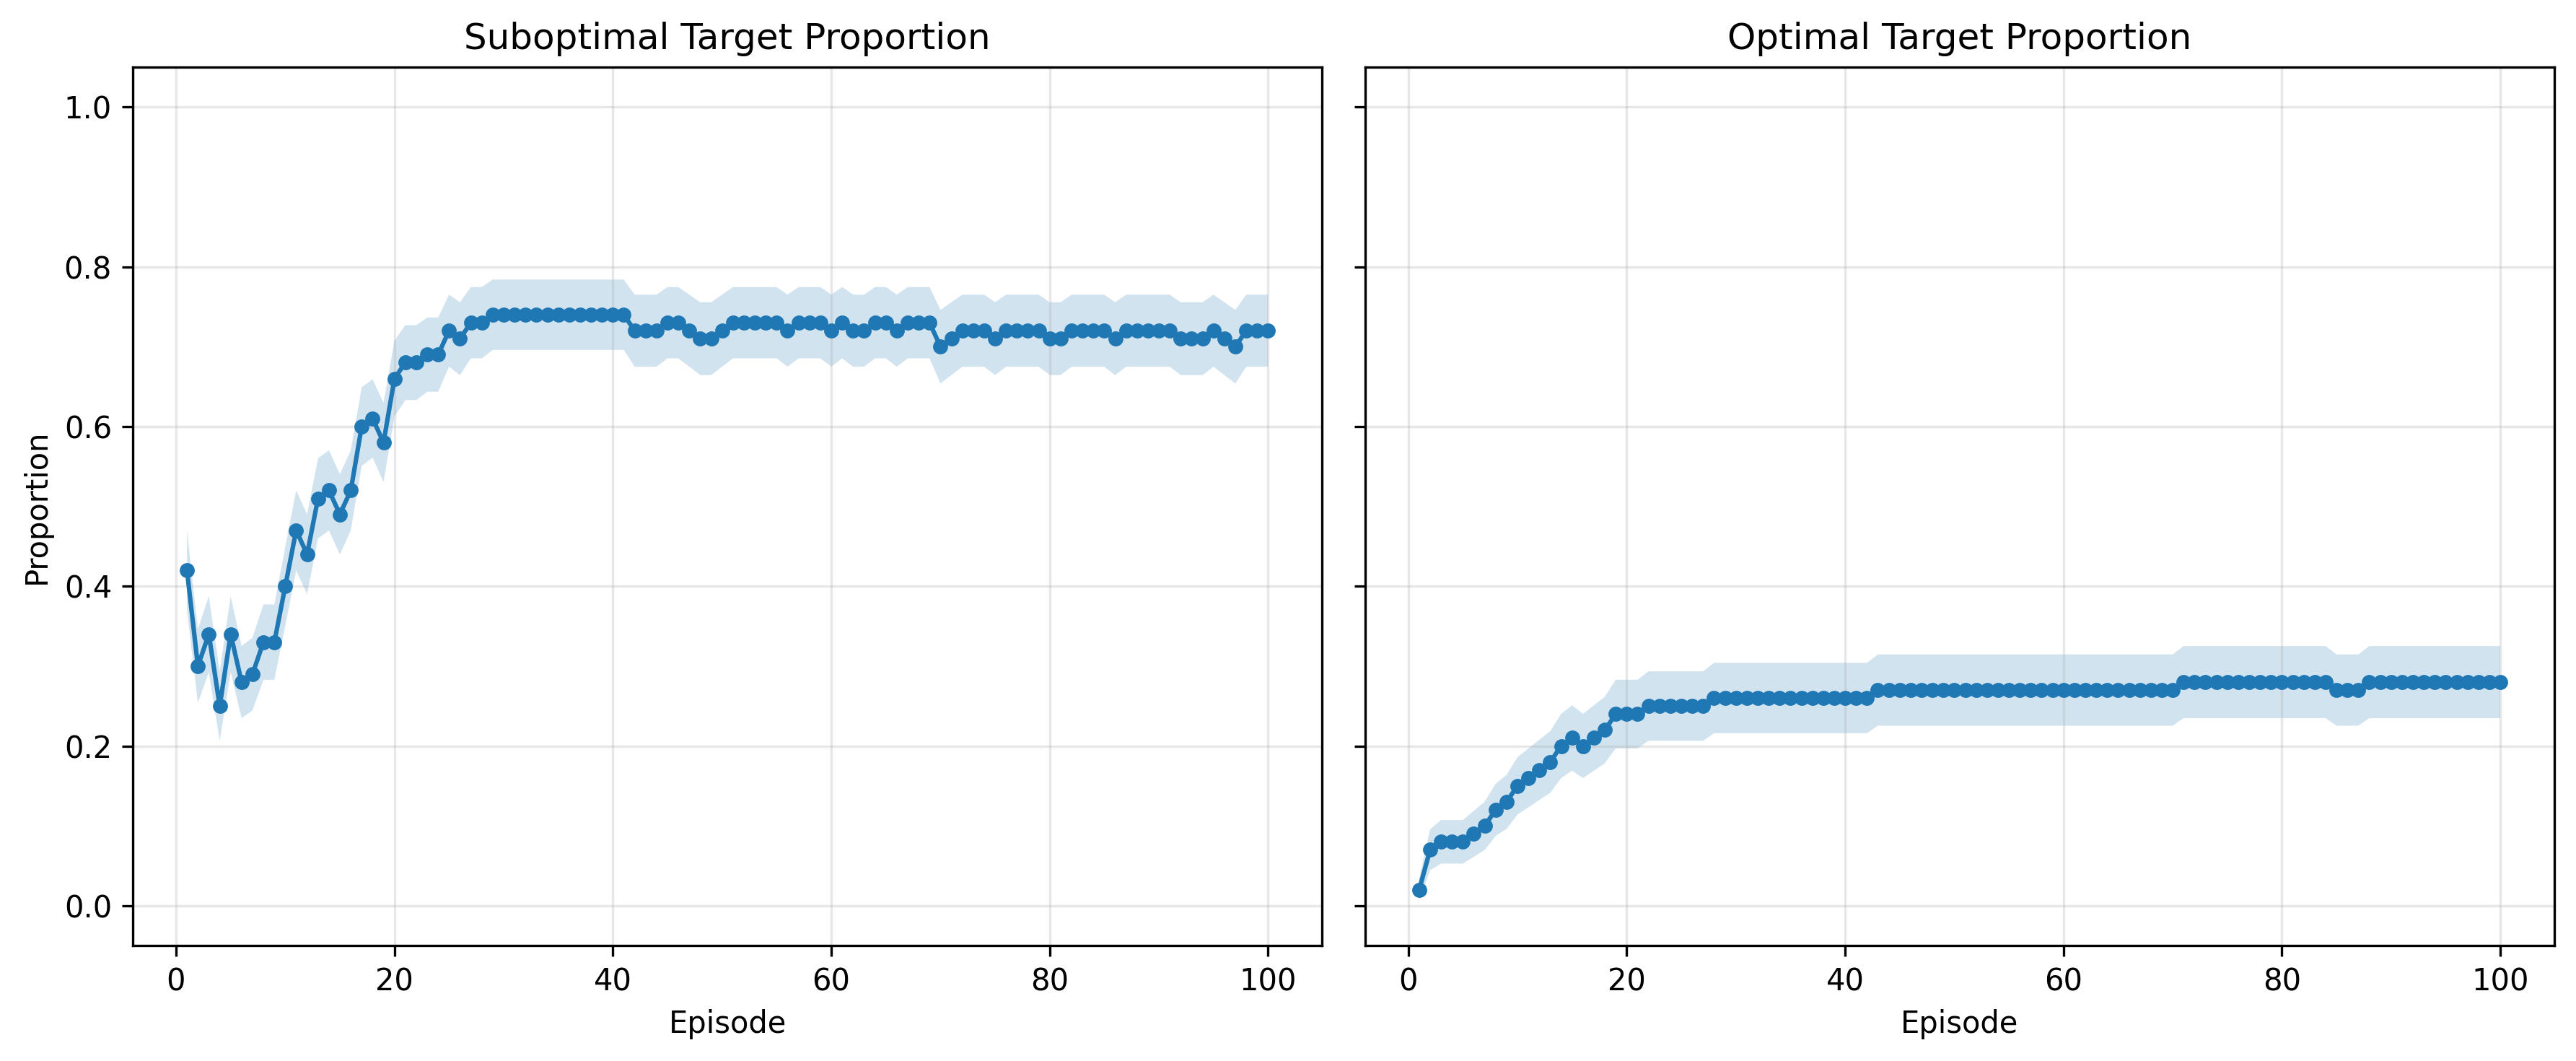

In [44]:
plt.rcParams["figure.dpi"] = 300
all_runs_opt = np.asarray(all_runs_opt, dtype=float)
all_runs_subopt = np.asarray(all_runs_subopt, dtype=float)


episodes = np.arange(1, all_runs_opt.shape[1] + 1)
n_runs_prop = all_runs_opt.shape[0]
opt_mean = all_runs_opt.mean(axis=0)
sub_mean = all_runs_subopt.mean(axis=0)
opt_std = all_runs_opt.std(axis=0, ddof=1)
sub_std = all_runs_subopt.std(axis=0, ddof=1)
opt_se = opt_std / np.sqrt(n_runs_prop)
sub_se = sub_std / np.sqrt(n_runs_prop)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


axes[0].plot(
    episodes,
    sub_mean,
    marker="o", markersize=4
)
axes[0].fill_between(episodes, sub_mean - sub_se, sub_mean + sub_se, alpha=0.2)
axes[0].set_title("Suboptimal Target Proportion")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)


axes[1].plot(
    episodes,
    opt_mean,
    marker="o", markersize=4
)
axes[1].fill_between(episodes, opt_mean - opt_se, opt_mean + opt_se, alpha=0.2)
axes[1].set_title("Optimal Target Proportion")
axes[1].set_xlabel("Episode")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()

### Questions
1. Agent shows improvement but settles for easier, low-value goals. Why does this happen? How can learning be improved?

2. How does the agent perform under different parameter configurations? <a href="https://huggingface.co/spaces/ngocntud/IBL-performance-comparator">
<img src="https://huggingface.co/datasets/huggingface/badges/raw/main/open-in-hf-spaces-sm.svg" alt="Open In Hugging Face Space"/>
</a>